In [201]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

#Carga de csvs para exploración

universo = pd.read_csv('data/universo.csv')

In [202]:
base_clientes = pd.read_csv('data/base_clientes.csv')
base_cuentas = pd.read_csv('data/base_saldos_cuentas.csv')

In [203]:
universo.head()

,ID,target,periodo
0,4d5a33701cb5b30b0b0a924d80de4ae78fbd0b54e2117f...,0,period_5
1,bf7092e5f394d266143dfe90b3fc73eac51f0b0084d7a3...,0,period_5
2,270d8f8f607d19886c50edb7746c3670194134b56d31e2...,0,period_5
3,5e6b7bea5e4911329669f45728d3398ad54dfe11fbb16d...,0,period_5
4,98954adf775b9fce1c9e311a025ec3e0a1c6e90f991ef7...,0,period_5


In [204]:
universo.shape

(535943, 3)

In [205]:
universo['target'].value_counts()

target
0    464075
1     47171
5      8489
4      6893
2      5929
3      3386
Name: count, dtype: int64

In [206]:
universo['target'].value_counts(normalize=True).sort_index() * 100

target
0    86.590365
1     8.801496
2     1.106274
3     0.631784
4     1.286144
5     1.583937
Name: proportion, dtype: float64

In [207]:
universo.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 535943 entries, 0 to 535942
Data columns (total 3 columns):
 #   Column   Non-Null Count   Dtype 
---  ------   --------------   ----- 
 0   ID       535943 non-null  object
 1   target   535943 non-null  int64 
 2   periodo  535943 non-null  object
dtypes: int64(1), object(2)
memory usage: 12.3+ MB


In [208]:
universo['target'].describe()

count    535943.000000
mean          0.259737
std           0.850548
min           0.000000
25%           0.000000
50%           0.000000
75%           0.000000
max           5.000000
Name: target, dtype: float64

In [209]:
universo.isnull().sum()


ID         0
target     0
periodo    0
dtype: int64

In [210]:
universo['periodo'].nunique()


6

In [211]:
base_clientes.head()

,ID,edad,ingreso,anios_exp,tipo_empleo,buro_de_credito,pago_nomina,tc,prest_per,prest_veh_hip,cuenta_ahorro,ofer_prest_per,ofer_tc,ofer_compra_deuda
0,42af3bf64c2c14307361e970e76c9653df78b215838971...,4.2484,4.1259,0.0,type_2,category_4,4.8095,Yes,No,No,Yes,No,No,No
1,5ab9acd6dc30e0e9361ca53e797b40f68841bd698d0926...,4.6903,3.9570,0.0,type_7,category_9,0.0000,No,No,No,Yes,No,No,No
2,8e40f988dd93417a0a40c32e65386425d891c879fedf4c...,4.1682,4.4640,0.0,type_7,category_5,0.0000,No,No,No,Yes,No,No,No
3,0e48974ce6e81d9e81a8da780521a2f98fb2385dc879df...,3.9651,4.0966,0.0,type_7,category_3,0.0000,Yes,Yes,Yes,Yes,No,No,No
4,e033c53b4fb230de5da6868503a9e079b289e064d62de4...,3.9576,4.1876,0.0,type_7,category_5,0.0000,Yes,No,No,Yes,No,No,No


In [212]:
base_clientes.shape

(809579, 14)

In [213]:
D1=base_clientes['ID'].duplicated().sum()
print(D1)

0


In [214]:
universo.rename(columns={'periodo': 'periodo_universo'}, inplace=True)

# 1. Primer merge
df_combinado_1 = pd.merge(universo, base_clientes, on='ID', how='left')

In [215]:
df_combinado_1.head()

,ID,target,periodo_universo,edad,ingreso,anios_exp,tipo_empleo,buro_de_credito,pago_nomina,tc,prest_per,prest_veh_hip,cuenta_ahorro,ofer_prest_per,ofer_tc,ofer_compra_deuda
0,4d5a33701cb5b30b0b0a924d80de4ae78fbd0b54e2117f...,0,period_5,3.8498,4.6527,0.000,type_2,category_6,0.0,No,No,No,Yes,No,No,No
1,bf7092e5f394d266143dfe90b3fc73eac51f0b0084d7a3...,0,period_5,4.5476,4.2447,4.274,type_3,category_4,0.0,No,No,No,Yes,No,No,No
2,270d8f8f607d19886c50edb7746c3670194134b56d31e2...,0,period_5,4.3600,4.2117,0.000,type_2,category_9,0.0,No,No,No,Yes,No,No,No
3,5e6b7bea5e4911329669f45728d3398ad54dfe11fbb16d...,0,period_5,4.3914,4.1584,0.000,type_7,category_2,0.0,No,No,No,Yes,Yes,Yes,No
4,98954adf775b9fce1c9e311a025ec3e0a1c6e90f991ef7...,0,period_5,4.3077,4.3285,0.000,type_2,category_6,0.0,No,No,No,Yes,No,No,No


In [216]:
df_combinado_1['periodo_universo'].value_counts()

periodo_universo
period_5    91539
period_6    91072
period_4    90920
period_3    88998
period_2    87386
period_1    86028
Name: count, dtype: int64

In [217]:
base_cuentas.shape

(8876560, 5)

In [218]:
base_cuentas.head()

,mes,ID,saldo_ahorros,saldo_otros,periodo
0,11,c7a6cecac361a970ee6c7cb9f2679c38c668940c6ebdc5...,4.1900,0.0,period_5
1,12,68f89dc7efe7cd1ce3cf6d52d8867bd2b84f236736bf91...,4.4621,0.0,period_5
2,2,e3f6afb18792d0b97cb9a63ad9567bbd106146c78d212a...,4.2878,0.0,period_5
3,1,8993170400939d522bdc72707527f5ab90202119fe3cab...,5.0000,5.0,period_5
4,7,399d686897232a55c713d61a6bdc7e232ab85b864d6288...,3.8922,0.0,period_5


In [219]:
D5=base_cuentas['ID'].duplicated().sum()
print(D5)

8085980


In [220]:
base_cuentas.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8876560 entries, 0 to 8876559
Data columns (total 5 columns):
 #   Column         Dtype  
---  ------         -----  
 0   mes            int64  
 1   ID             object 
 2   saldo_ahorros  float64
 3   saldo_otros    float64
 4   periodo        object 
dtypes: float64(2), int64(1), object(2)
memory usage: 338.6+ MB


In [221]:
base_cuentas.groupby('periodo')['mes'].nunique()

periodo
period_1    12
period_2    12
period_3    12
period_4    12
period_5    12
period_6    12
period_7    12
period_8    12
period_9    12
Name: mes, dtype: int64

In [222]:
a=base_cuentas.groupby('ID')['periodo'].nunique().reset_index(name='num_periodos')

a.describe()


,num_periodos
count,790580.0
mean,1.0
std,0.0
min,1.0
25%,1.0
50%,1.0
75%,1.0
max,1.0


**De aca se deduce que el ID de un cliente esta en un solo periodo**

In [223]:
base_agg = base_cuentas.groupby('ID').agg(
    periodo_max=('periodo', 'max'),
    mes_max=('mes', 'max')
).reset_index()


meses_3m = [10, 11, 12]
meses_6m = [7, 8, 9, 10, 11, 12]
meses_9m = [4, 5, 6, 7, 8, 9, 10, 11, 12]
meses_12m = [1,2,3,4, 5, 6, 7, 8, 9, 10, 11, 12]


df_3m = base_cuentas[base_cuentas['mes'].isin(meses_3m)]


agg_3m = df_3m.groupby('ID').agg(
    saldo_ahorros_sum_3m=('saldo_ahorros', 'sum'),
    saldo_ahorros_mean_3m=('saldo_ahorros', 'mean'),
    saldo_ahorros_max_3m=('saldo_ahorros', 'max'),
    saldo_otros_sum_3m=('saldo_otros', 'sum'),
    saldo_otros_mean_3m=('saldo_otros', 'mean'),
    saldo_otros_max_3m=('saldo_otros', 'max')
).reset_index()


df_6m = base_cuentas[base_cuentas['mes'].isin(meses_6m)]

agg_6m = df_6m.groupby('ID').agg(
    saldo_ahorros_sum_6m=('saldo_ahorros', 'sum'),
    saldo_ahorros_mean_6m=('saldo_ahorros', 'mean'),
    saldo_ahorros_max_6m=('saldo_ahorros', 'max'),
    saldo_otros_sum_6m=('saldo_otros', 'sum'),
    saldo_otros_mean_6m=('saldo_otros', 'mean'),
    saldo_otros_max_6m=('saldo_otros', 'max')
).reset_index()


df_9m = base_cuentas[base_cuentas['mes'].isin(meses_9m)]

agg_9m = df_9m.groupby('ID').agg(
    saldo_ahorros_sum_9m=('saldo_ahorros', 'sum'),
    saldo_ahorros_mean_9m=('saldo_ahorros', 'mean'),
    saldo_ahorros_max_9m=('saldo_ahorros', 'max'),
    saldo_otros_sum_9m=('saldo_otros', 'sum'),
    saldo_otros_mean_9m=('saldo_otros', 'mean'),
    saldo_otros_max_9m=('saldo_otros', 'max')
).reset_index()



df_12m = base_cuentas[base_cuentas['mes'].isin(meses_12m)]

agg_12m = df_12m.groupby('ID').agg(
    saldo_ahorros_sum_12m=('saldo_ahorros', 'sum'),
    saldo_ahorros_mean_12m=('saldo_ahorros', 'mean'),
    saldo_ahorros_max_12m=('saldo_ahorros', 'max'),
    saldo_otros_sum_12m=('saldo_otros', 'sum'),
    saldo_otros_mean_12m=('saldo_otros', 'mean'),
    saldo_otros_max_12m=('saldo_otros', 'max')
).reset_index()


base_cuentas_agrupado = base_agg


base_cuentas_agrupado = base_cuentas_agrupado.merge(
    agg_3m, 
    on='ID', 
    how='left'
)


base_cuentas_agrupado = base_cuentas_agrupado.merge(
    agg_6m, 
    on='ID', 
    how='left'
)


base_cuentas_agrupado = base_cuentas_agrupado.merge(
    agg_9m, 
    on='ID', 
    how='left'
)

base_cuentas_agrupado = base_cuentas_agrupado.merge(
    agg_12m, 
    on='ID', 
    how='left'
)

In [224]:
nulos_porcentaje = (base_cuentas_agrupado.isnull().mean() * 100).sort_values(ascending=False)
print(nulos_porcentaje)

saldo_ahorros_max_3m      0.536315
saldo_ahorros_mean_3m     0.536315
saldo_ahorros_sum_3m      0.536315
saldo_otros_mean_3m       0.536315
saldo_otros_max_3m        0.536315
saldo_otros_sum_3m        0.536315
saldo_ahorros_sum_6m      0.243619
saldo_ahorros_mean_6m     0.243619
saldo_otros_mean_6m       0.243619
saldo_otros_sum_6m        0.243619
saldo_ahorros_max_6m      0.243619
saldo_otros_max_6m        0.243619
saldo_otros_mean_9m       0.097523
saldo_ahorros_max_9m      0.097523
saldo_otros_max_9m        0.097523
saldo_ahorros_sum_9m      0.097523
saldo_ahorros_mean_9m     0.097523
saldo_otros_sum_9m        0.097523
mes_max                   0.000000
periodo_max               0.000000
ID                        0.000000
saldo_ahorros_sum_12m     0.000000
saldo_ahorros_mean_12m    0.000000
saldo_ahorros_max_12m     0.000000
saldo_otros_sum_12m       0.000000
saldo_otros_mean_12m      0.000000
saldo_otros_max_12m       0.000000
dtype: float64


In [225]:
base_cuentas_agrupado.describe()

,mes_max,saldo_ahorros_sum_3m,saldo_ahorros_mean_3m,saldo_ahorros_max_3m,saldo_otros_sum_3m,saldo_otros_mean_3m,saldo_otros_max_3m,saldo_ahorros_sum_6m,saldo_ahorros_mean_6m,saldo_ahorros_max_6m,...,saldo_ahorros_max_9m,saldo_otros_sum_9m,saldo_otros_mean_9m,saldo_otros_max_9m,saldo_ahorros_sum_12m,saldo_ahorros_mean_12m,saldo_ahorros_max_12m,saldo_otros_sum_12m,saldo_otros_mean_12m,saldo_otros_max_12m
count,790580.000000,786340.000000,786340.000000,786340.000000,786340.000000,786340.000000,786340.000000,788654.000000,788654.000000,788654.000000,...,789809.000000,789809.000000,789809.000000,789809.000000,790580.000000,790580.000000,790580.000000,790580.000000,790580.000000,790580.000000
mean,11.960378,9.455080,3.183822,3.423922,1.902803,0.637057,0.759398,18.412806,3.149667,3.552320,...,3.635771,5.323355,0.602463,0.895451,35.263194,3.114804,3.698735,6.951953,0.594709,0.929043
std,0.472062,3.325055,1.085292,1.054301,4.107550,1.373959,1.533803,6.860666,1.081263,1.032449,...,1.021139,11.490163,1.291970,1.651570,14.586517,1.084318,1.013600,15.088684,1.277172,1.684191
min,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,12.000000,8.276300,2.786733,3.087600,0.000000,0.000000,0.000000,15.614300,2.720233,3.201100,...,3.271500,0.000000,0.000000,0.000000,27.821900,2.637523,3.330400,0.000000,0.000000,0.000000
50%,12.000000,9.778100,3.276800,3.536900,0.000000,0.000000,0.000000,19.252750,3.247967,3.672600,...,3.763900,0.000000,0.000000,0.000000,37.591600,3.223662,3.835800,0.000000,0.000000,0.000000
75%,12.000000,11.667900,3.899233,4.087900,0.015900,0.005300,0.005300,23.060700,3.866133,4.204600,...,4.286300,1.174500,0.132978,0.169800,45.606325,3.847860,4.348500,2.205500,0.192592,0.364400
max,12.000000,15.000000,5.000000,5.000000,15.000000,5.000000,5.000000,30.000000,5.000000,5.000000,...,5.000000,45.000000,5.000000,5.000000,60.000000,5.000000,5.000000,60.000000,5.000000,5.000000


In [226]:
df_PSC = pd.merge(df_combinado_1, base_cuentas_agrupado, on='ID', how='left')

In [227]:
df_PSC.describe()

,target,edad,ingreso,anios_exp,pago_nomina,mes_max,saldo_ahorros_sum_3m,saldo_ahorros_mean_3m,saldo_ahorros_max_3m,saldo_otros_sum_3m,...,saldo_ahorros_max_9m,saldo_otros_sum_9m,saldo_otros_mean_9m,saldo_otros_max_9m,saldo_ahorros_sum_12m,saldo_ahorros_mean_12m,saldo_ahorros_max_12m,saldo_otros_sum_12m,saldo_otros_mean_12m,saldo_otros_max_12m
count,535943.000000,535943.000000,535943.000000,535943.000000,535943.000000,523646.000000,521310.000000,521310.000000,521310.000000,521310.000000,...,523180.000000,523180.000000,523180.000000,523180.000000,523646.000000,523646.000000,523646.000000,523646.000000,523646.000000,523646.000000
mean,0.259737,4.274235,4.285165,1.326926,1.433891,11.966810,9.454759,3.183288,3.423932,1.939582,...,3.640502,5.306518,0.600046,0.892244,35.381396,3.125718,3.704595,7.002794,0.598199,0.931193
std,0.850548,0.378866,0.472804,1.942356,2.020475,0.439026,3.306562,1.079892,1.049790,4.127986,...,1.021531,11.485674,1.290271,1.646745,14.580697,1.082984,1.014609,15.167091,1.281849,1.686373
min,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.000000,3.999900,4.105400,0.000000,0.000000,12.000000,8.276625,2.787067,3.090000,0.000000,...,3.274400,0.000000,0.000000,0.000000,28.049000,2.651100,3.336600,0.000000,0.000000,0.000000
50%,0.000000,4.265800,4.283400,0.000000,0.000000,12.000000,9.763850,3.272117,3.533600,0.000000,...,3.770500,0.000000,0.000000,0.000000,37.743750,3.237150,3.846300,0.000000,0.000000,0.000000
75%,0.000000,4.548900,4.503500,3.602900,3.979200,12.000000,11.643600,3.891467,4.080700,0.015900,...,4.293000,1.138500,0.127303,0.154300,45.733300,3.859549,4.355000,2.315575,0.198990,0.369200
max,5.000000,5.000000,5.000000,5.000000,5.000000,12.000000,15.000000,5.000000,5.000000,15.000000,...,5.000000,45.000000,5.000000,5.000000,60.000000,5.000000,5.000000,60.000000,5.000000,5.000000


In [228]:
df_PSC.head()

,ID,target,periodo_universo,edad,ingreso,anios_exp,tipo_empleo,buro_de_credito,pago_nomina,tc,...,saldo_ahorros_max_9m,saldo_otros_sum_9m,saldo_otros_mean_9m,saldo_otros_max_9m,saldo_ahorros_sum_12m,saldo_ahorros_mean_12m,saldo_ahorros_max_12m,saldo_otros_sum_12m,saldo_otros_mean_12m,saldo_otros_max_12m
0,4d5a33701cb5b30b0b0a924d80de4ae78fbd0b54e2117f...,0,period_5,3.8498,4.6527,0.000,type_2,category_6,0.0,No,...,3.8144,0.0,0.0,0.0,39.5354,3.294617,4.1174,0.0,0.0,0.0
1,bf7092e5f394d266143dfe90b3fc73eac51f0b0084d7a3...,0,period_5,4.5476,4.2447,4.274,type_3,category_4,0.0,No,...,3.5339,0.0,0.0,0.0,40.5731,3.381092,3.5592,0.0,0.0,0.0
2,270d8f8f607d19886c50edb7746c3670194134b56d31e2...,0,period_5,4.3600,4.2117,0.000,type_2,category_9,0.0,No,...,3.9148,0.0,0.0,0.0,42.1470,3.512250,3.9182,0.0,0.0,0.0
3,5e6b7bea5e4911329669f45728d3398ad54dfe11fbb16d...,0,period_5,4.3914,4.1584,0.000,type_7,category_2,0.0,No,...,3.9088,0.0,0.0,0.0,46.6400,3.886667,4.0929,0.0,0.0,0.0
4,98954adf775b9fce1c9e311a025ec3e0a1c6e90f991ef7...,0,period_5,4.3077,4.3285,0.000,type_2,category_6,0.0,No,...,3.4086,0.0,0.0,0.0,35.3925,2.949375,3.4086,0.0,0.0,0.0


In [229]:
nulos_porcentaje = (df_PSC.isnull().mean() * 100).sort_values(ascending=False)
print(nulos_porcentaje)

saldo_ahorros_max_3m      2.730328
saldo_otros_sum_3m        2.730328
saldo_otros_mean_3m       2.730328
saldo_otros_max_3m        2.730328
saldo_ahorros_sum_3m      2.730328
saldo_ahorros_mean_3m     2.730328
saldo_ahorros_sum_6m      2.498773
saldo_ahorros_mean_6m     2.498773
saldo_otros_mean_6m       2.498773
saldo_otros_max_6m        2.498773
saldo_otros_sum_6m        2.498773
saldo_ahorros_max_6m      2.498773
saldo_otros_mean_9m       2.381410
saldo_otros_max_9m        2.381410
saldo_otros_sum_9m        2.381410
saldo_ahorros_max_9m      2.381410
saldo_ahorros_mean_9m     2.381410
saldo_ahorros_sum_9m      2.381410
saldo_otros_mean_12m      2.294460
saldo_otros_max_12m       2.294460
saldo_ahorros_sum_12m     2.294460
saldo_ahorros_mean_12m    2.294460
saldo_ahorros_max_12m     2.294460
saldo_otros_sum_12m       2.294460
periodo_max               2.294460
mes_max                   2.294460
tc                        0.000000
pago_nomina               0.000000
buro_de_credito     

In [230]:
df_PSC.head()

,ID,target,periodo_universo,edad,ingreso,anios_exp,tipo_empleo,buro_de_credito,pago_nomina,tc,...,saldo_ahorros_max_9m,saldo_otros_sum_9m,saldo_otros_mean_9m,saldo_otros_max_9m,saldo_ahorros_sum_12m,saldo_ahorros_mean_12m,saldo_ahorros_max_12m,saldo_otros_sum_12m,saldo_otros_mean_12m,saldo_otros_max_12m
0,4d5a33701cb5b30b0b0a924d80de4ae78fbd0b54e2117f...,0,period_5,3.8498,4.6527,0.000,type_2,category_6,0.0,No,...,3.8144,0.0,0.0,0.0,39.5354,3.294617,4.1174,0.0,0.0,0.0
1,bf7092e5f394d266143dfe90b3fc73eac51f0b0084d7a3...,0,period_5,4.5476,4.2447,4.274,type_3,category_4,0.0,No,...,3.5339,0.0,0.0,0.0,40.5731,3.381092,3.5592,0.0,0.0,0.0
2,270d8f8f607d19886c50edb7746c3670194134b56d31e2...,0,period_5,4.3600,4.2117,0.000,type_2,category_9,0.0,No,...,3.9148,0.0,0.0,0.0,42.1470,3.512250,3.9182,0.0,0.0,0.0
3,5e6b7bea5e4911329669f45728d3398ad54dfe11fbb16d...,0,period_5,4.3914,4.1584,0.000,type_7,category_2,0.0,No,...,3.9088,0.0,0.0,0.0,46.6400,3.886667,4.0929,0.0,0.0,0.0
4,98954adf775b9fce1c9e311a025ec3e0a1c6e90f991ef7...,0,period_5,4.3077,4.3285,0.000,type_2,category_6,0.0,No,...,3.4086,0.0,0.0,0.0,35.3925,2.949375,3.4086,0.0,0.0,0.0


# Análisis de Nulos y Valores Atípicos

## 1. Visualización de Nulos

In [231]:
# Calcular porcentaje de nulos por columna
nulos_df = pd.DataFrame({
    'Variable': df_PSC.columns,
    'Nulos': df_PSC.isnull().sum(),
    'Porcentaje': (df_PSC.isnull().sum() / len(df_PSC) * 100)
}).sort_values('Porcentaje', ascending=False)

# Mostrar solo variables con nulos
nulos_df_filtrado = nulos_df[nulos_df['Nulos'] > 0]
print(nulos_df_filtrado)

                                      Variable  Nulos  Porcentaje
saldo_ahorros_max_3m      saldo_ahorros_max_3m  14633    2.730328
saldo_otros_sum_3m          saldo_otros_sum_3m  14633    2.730328
saldo_otros_mean_3m        saldo_otros_mean_3m  14633    2.730328
saldo_otros_max_3m          saldo_otros_max_3m  14633    2.730328
saldo_ahorros_sum_3m      saldo_ahorros_sum_3m  14633    2.730328
saldo_ahorros_mean_3m    saldo_ahorros_mean_3m  14633    2.730328
saldo_ahorros_sum_6m      saldo_ahorros_sum_6m  13392    2.498773
saldo_ahorros_mean_6m    saldo_ahorros_mean_6m  13392    2.498773
saldo_otros_mean_6m        saldo_otros_mean_6m  13392    2.498773
saldo_otros_max_6m          saldo_otros_max_6m  13392    2.498773
saldo_otros_sum_6m          saldo_otros_sum_6m  13392    2.498773
saldo_ahorros_max_6m      saldo_ahorros_max_6m  13392    2.498773
saldo_otros_mean_9m        saldo_otros_mean_9m  12763    2.381410
saldo_otros_max_9m          saldo_otros_max_9m  12763    2.381410
saldo_otro

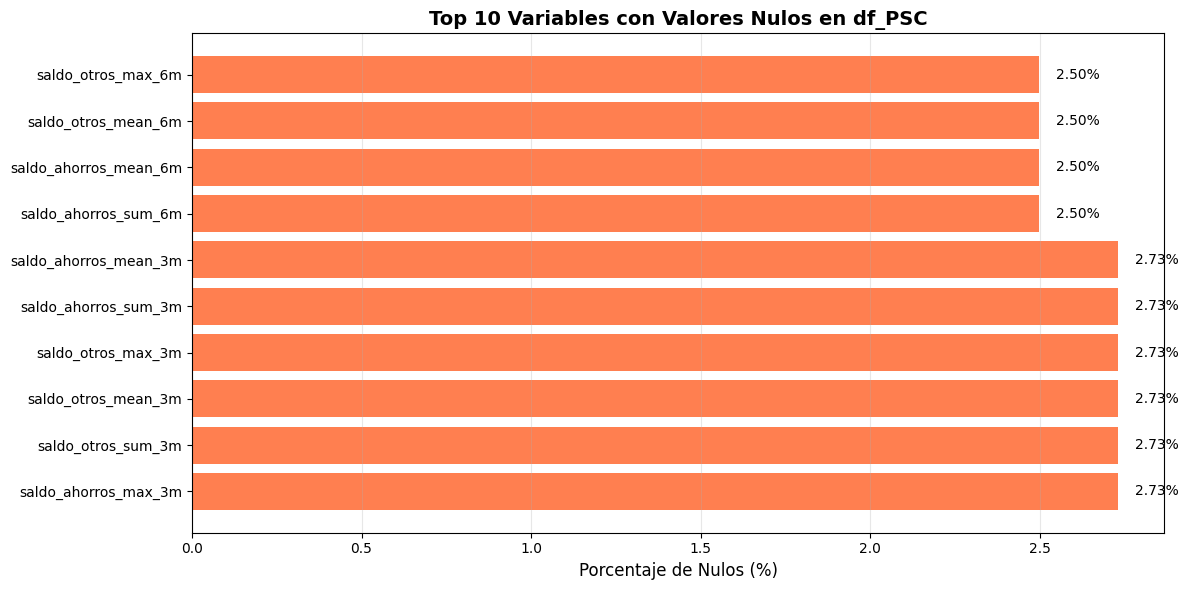

In [232]:
# Visualización de nulos
fig, ax = plt.subplots(figsize=(12, 6))
variables_con_nulos = nulos_df_filtrado['Variable'].head(10)
porcentajes = nulos_df_filtrado['Porcentaje'].head(10)

ax.barh(variables_con_nulos, porcentajes, color='coral')
ax.set_xlabel('Porcentaje de Nulos (%)', fontsize=12)
ax.set_title('Top 10 Variables con Valores Nulos en df_PSC', fontsize=14, fontweight='bold')
ax.grid(axis='x', alpha=0.3)

for i, v in enumerate(porcentajes):
    ax.text(v + 0.05, i, f'{v:.2f}%', va='center', fontsize=10)

plt.tight_layout()
plt.show()


## 2. Análisis de Distribuciones - Histogramas

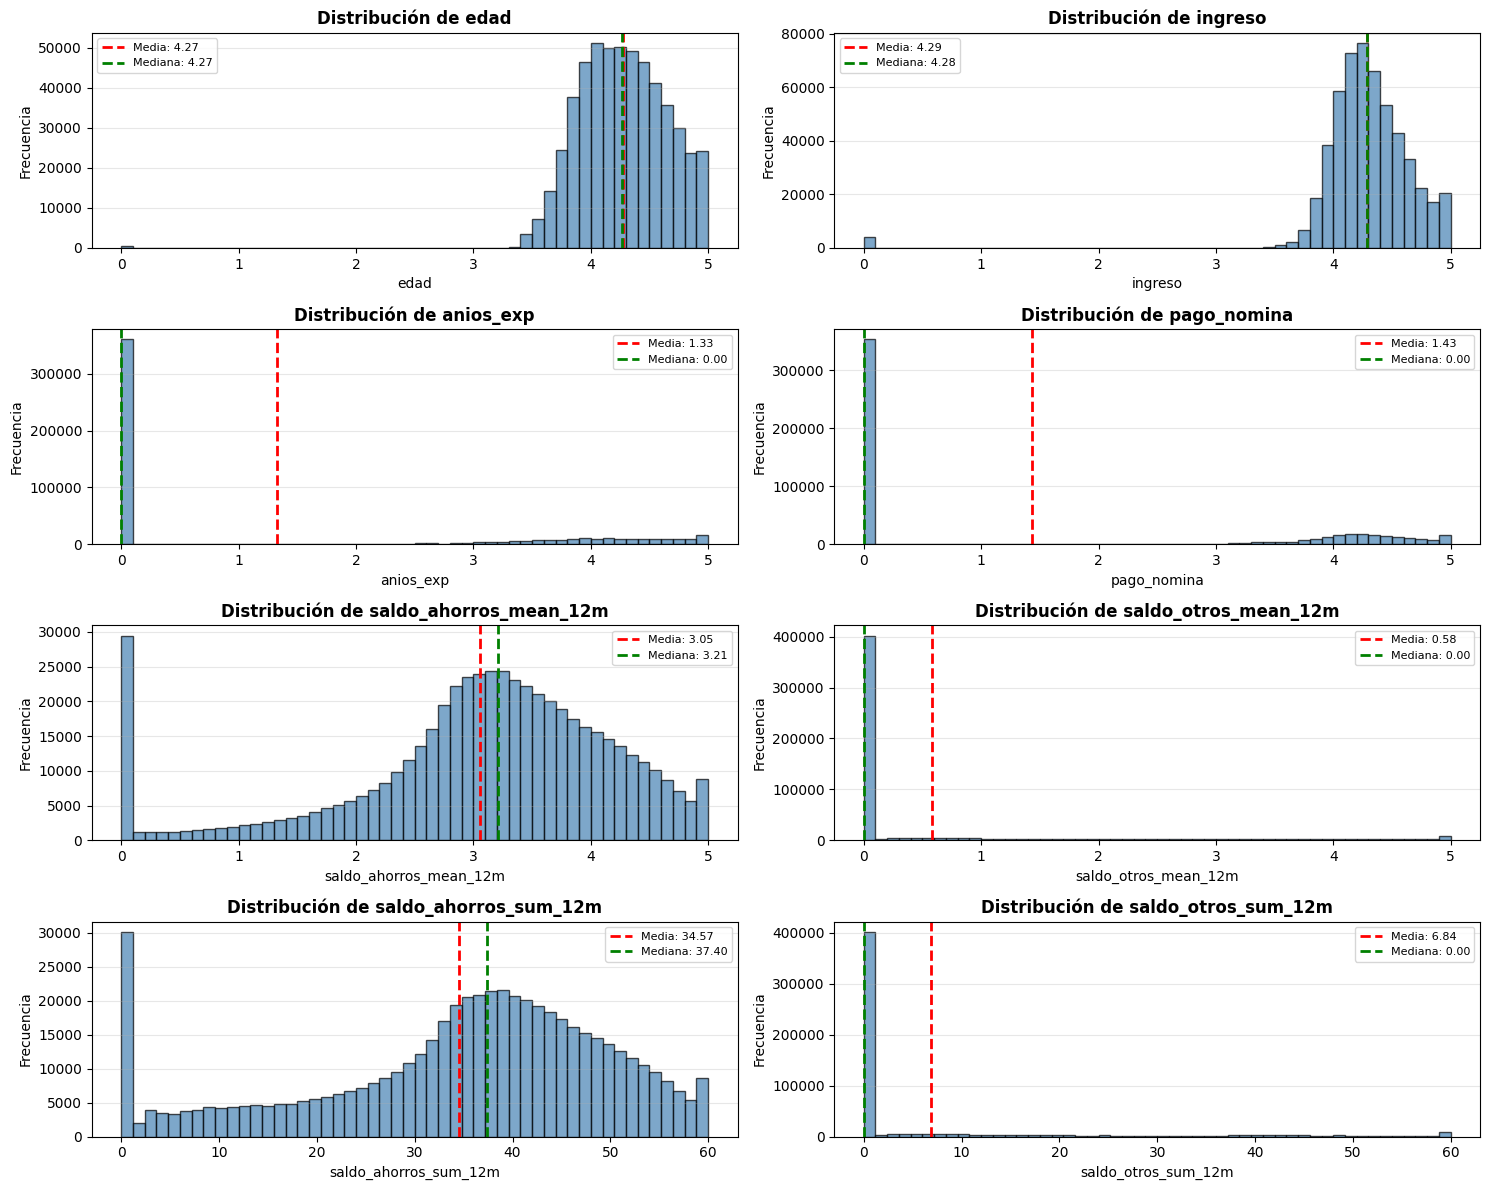

In [245]:
# Seleccionar variables numéricas para analizar
vars_numericas = ['edad', 'ingreso', 'anios_exp', 'pago_nomina', 
                  'saldo_ahorros_mean_12m', 'saldo_otros_mean_12m',
                  'saldo_ahorros_sum_12m', 'saldo_otros_sum_12m']

# Crear histogramas
fig, axes = plt.subplots(4, 2, figsize=(15, 12))
axes = axes.ravel()

for i, var in enumerate(vars_numericas):
    if var in df_PSC.columns:
        # Eliminar nulos para la visualización
        data = df_PSC[var].dropna()
        
        axes[i].hist(data, bins=50, edgecolor='black', alpha=0.7, color='steelblue')
        axes[i].set_title(f'Distribución de {var}', fontsize=12, fontweight='bold')
        axes[i].set_xlabel(var, fontsize=10)
        axes[i].set_ylabel('Frecuencia', fontsize=10)
        axes[i].grid(axis='y', alpha=0.3)
        
        # Agregar estadísticas
        mean_val = data.mean()
        median_val = data.median()
        axes[i].axvline(mean_val, color='red', linestyle='--', linewidth=2, label=f'Media: {mean_val:.2f}')
        axes[i].axvline(median_val, color='green', linestyle='--', linewidth=2, label=f'Mediana: {median_val:.2f}')
        axes[i].legend(fontsize=8)

plt.tight_layout()
plt.show()

## 3. Boxplots para Identificar Outliers

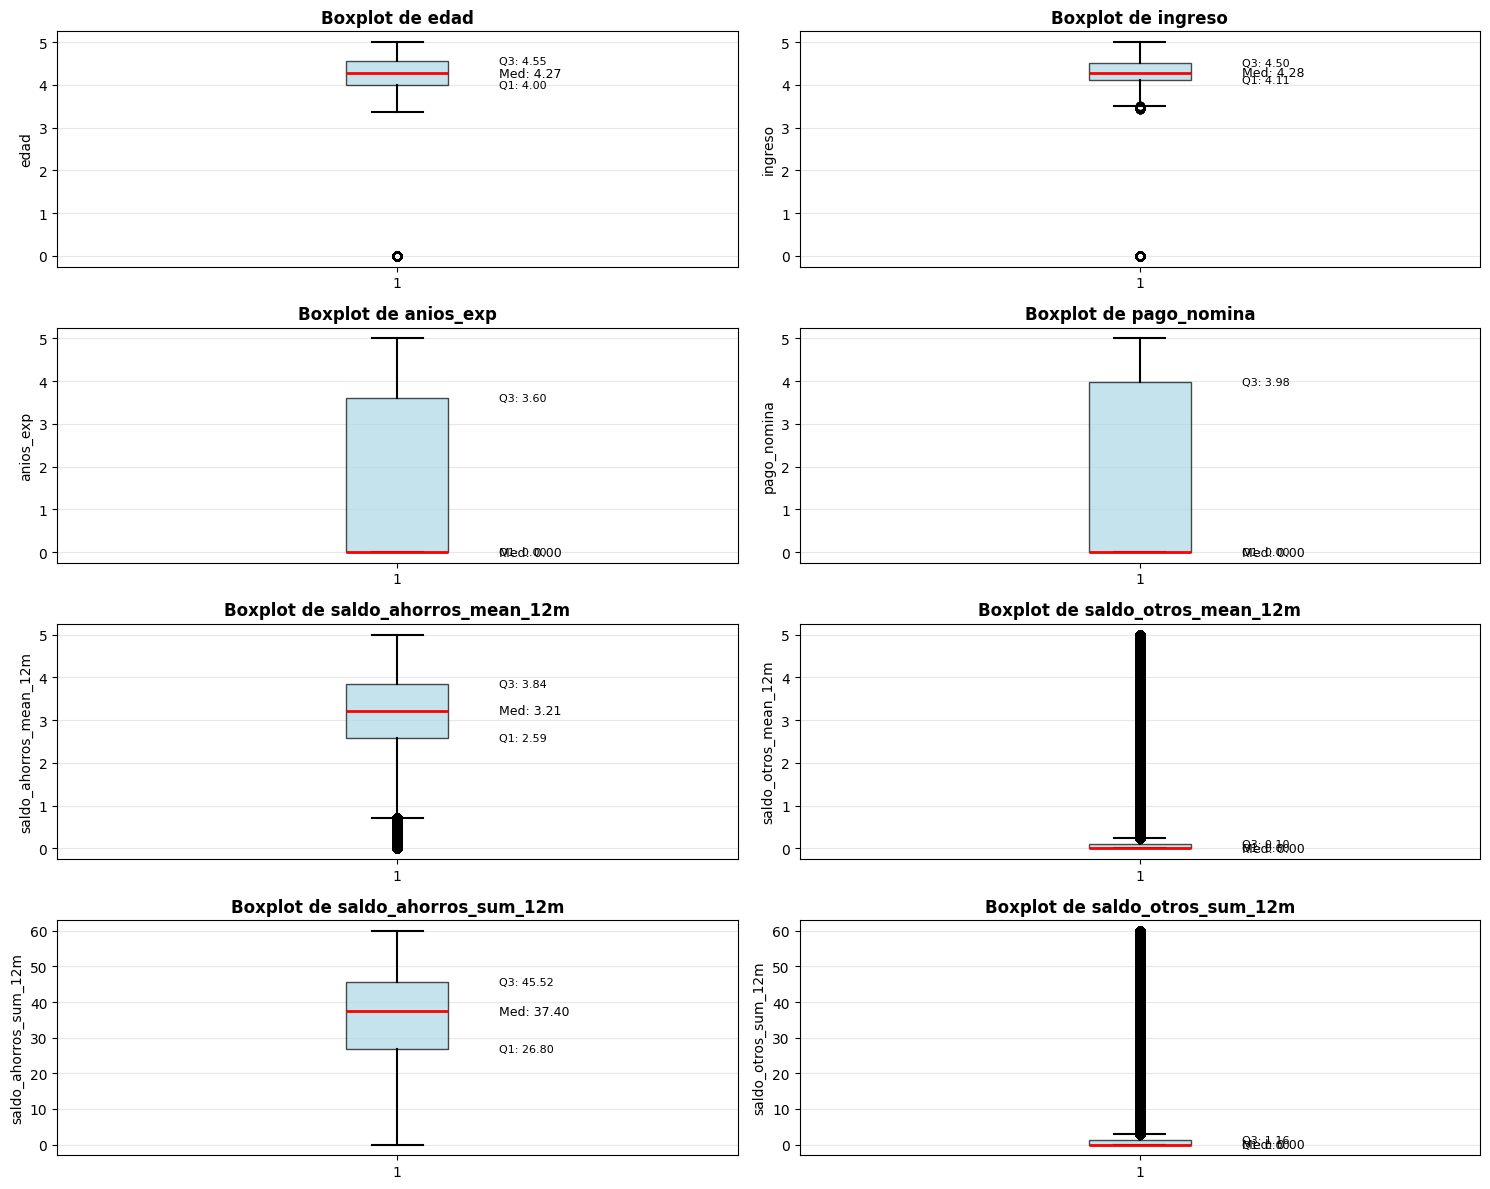

In [246]:
# Boxplots para variables numéricas
fig, axes = plt.subplots(4, 2, figsize=(15, 12))
axes = axes.ravel()

for i, var in enumerate(vars_numericas):
    if var in df_PSC.columns:
        data = df_PSC[var].dropna()
        
        axes[i].boxplot(data, vert=True, patch_artist=True,
                       boxprops=dict(facecolor='lightblue', alpha=0.7),
                       medianprops=dict(color='red', linewidth=2),
                       whiskerprops=dict(color='black', linewidth=1.5),
                       capprops=dict(color='black', linewidth=1.5))
        
        axes[i].set_title(f'Boxplot de {var}', fontsize=12, fontweight='bold')
        axes[i].set_ylabel(var, fontsize=10)
        axes[i].grid(axis='y', alpha=0.3)
        
        # Agregar estadísticas
        q1 = data.quantile(0.25)
        q3 = data.quantile(0.75)
        median = data.median()
        axes[i].text(1.15, median, f'Med: {median:.2f}', fontsize=9, va='center')
        axes[i].text(1.15, q1, f'Q1: {q1:.2f}', fontsize=8, va='center')
        axes[i].text(1.15, q3, f'Q3: {q3:.2f}', fontsize=8, va='center')

plt.tight_layout()
plt.show()

In [235]:
def calcular_outliers_iqr(data, columna):

    Q1 = data[columna].quantile(0.25)
    Q3 = data[columna].quantile(0.75)
    IQR = Q3 - Q1
    
    limite_inferior = Q1 - 1.5 * IQR
    limite_superior = Q3 + 1.5 * IQR
    
    outliers = data[(data[columna] < limite_inferior) | (data[columna] > limite_superior)]
    num_outliers = len(outliers)
    porcentaje_outliers = (num_outliers / len(data[columna].dropna())) * 100
    
    return {
        'Q1': Q1,
        'Q3': Q3,
        'IQR': IQR,
        'Limite_Inferior': limite_inferior,
        'Limite_Superior': limite_superior,
        'Num_Outliers': num_outliers,
        'Porcentaje_Outliers': porcentaje_outliers
    }

# Calcular outliers para todas las variables numéricas
outliers_info = []

for var in vars_numericas:
    if var in df_PSC.columns:
        info = calcular_outliers_iqr(df_PSC, var)
        info['Variable'] = var
        outliers_info.append(info)

# Crear DataFrame con información de outliers
df_outliers = pd.DataFrame(outliers_info)
df_outliers = df_outliers[['Variable', 'Q1', 'Q3', 'IQR', 'Limite_Inferior', 
                           'Limite_Superior', 'Num_Outliers', 'Porcentaje_Outliers']]


print("OUTLIERS POR VARIABLE (Método IQR)")
print(df_outliers.to_string(index=False))
print("\n")

OUTLIERS POR VARIABLE (Método IQR)
              Variable      Q1        Q3       IQR  Limite_Inferior  Limite_Superior  Num_Outliers  Porcentaje_Outliers
                  edad  3.9999  4.548900  0.549000         3.176400         5.372400           401             0.074821
               ingreso  4.1054  4.503500  0.398100         3.508250         5.100650          4269             0.796540
             anios_exp  0.0000  3.602900  3.602900        -5.404350         9.007250             0             0.000000
           pago_nomina  0.0000  3.979200  3.979200        -5.968800         9.948000             0             0.000000
saldo_ahorros_mean_12m  2.6511  3.859549  1.208449         0.838427         5.672222         26910             5.138968
  saldo_otros_mean_12m  0.0000  0.198990  0.198990        -0.298484         0.497474        119293            22.781230
 saldo_ahorros_sum_12m 28.0490 45.733300 17.684300         1.522550        72.259750         18346             3.503512
   sa

In [236]:
# Identificar todas las columnas de saldos con nulos
cols_saldos = [col for col in df_PSC.columns if 'saldo' in col or col in ['mes_max', 'periodo_max']]

print("IMPUTACIÓN DE VALORES NULOS POR CERO")
print("\nColumnas de saldos a imputar:")
for col in cols_saldos:
    nulos_antes = df_PSC[col].isnull().sum()
    if nulos_antes > 0:
        print(f"  - {col}: {nulos_antes:,} nulos ({(nulos_antes/len(df_PSC)*100):.2f}%)")

# Imputar con cero
for col in cols_saldos:
    if col in df_PSC.columns:
        df_PSC[col].fillna(0, inplace=True)




IMPUTACIÓN DE VALORES NULOS POR CERO

Columnas de saldos a imputar:
  - periodo_max: 12,297 nulos (2.29%)
  - mes_max: 12,297 nulos (2.29%)
  - saldo_ahorros_sum_3m: 14,633 nulos (2.73%)
  - saldo_ahorros_mean_3m: 14,633 nulos (2.73%)
  - saldo_ahorros_max_3m: 14,633 nulos (2.73%)
  - saldo_otros_sum_3m: 14,633 nulos (2.73%)
  - saldo_otros_mean_3m: 14,633 nulos (2.73%)
  - saldo_otros_max_3m: 14,633 nulos (2.73%)
  - saldo_ahorros_sum_6m: 13,392 nulos (2.50%)
  - saldo_ahorros_mean_6m: 13,392 nulos (2.50%)
  - saldo_ahorros_max_6m: 13,392 nulos (2.50%)
  - saldo_otros_sum_6m: 13,392 nulos (2.50%)
  - saldo_otros_mean_6m: 13,392 nulos (2.50%)
  - saldo_otros_max_6m: 13,392 nulos (2.50%)
  - saldo_ahorros_sum_9m: 12,763 nulos (2.38%)
  - saldo_ahorros_mean_9m: 12,763 nulos (2.38%)
  - saldo_ahorros_max_9m: 12,763 nulos (2.38%)
  - saldo_otros_sum_9m: 12,763 nulos (2.38%)
  - saldo_otros_mean_9m: 12,763 nulos (2.38%)
  - saldo_otros_max_9m: 12,763 nulos (2.38%)
  - saldo_ahorros_sum_12m:

C:\Users\jlpar\AppData\Local\Temp\ipykernel_15792\1948848272.py:14: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df_PSC[col].fillna(0, inplace=True)


In [237]:
# Verificar que no queden nulos
nulos_despues = df_PSC[cols_saldos].isnull().sum().sum()
print(f"\nNulos restantes: {nulos_despues}")


Nulos restantes: 0


In [238]:
nulos_porcentaje = (df_PSC.isnull().mean() * 100).sort_values(ascending=False)
print(nulos_porcentaje)

ID                        0.0
target                    0.0
periodo_universo          0.0
edad                      0.0
ingreso                   0.0
anios_exp                 0.0
tipo_empleo               0.0
buro_de_credito           0.0
pago_nomina               0.0
tc                        0.0
prest_per                 0.0
prest_veh_hip             0.0
cuenta_ahorro             0.0
ofer_prest_per            0.0
ofer_tc                   0.0
ofer_compra_deuda         0.0
periodo_max               0.0
mes_max                   0.0
saldo_ahorros_sum_3m      0.0
saldo_ahorros_mean_3m     0.0
saldo_ahorros_max_3m      0.0
saldo_otros_sum_3m        0.0
saldo_otros_mean_3m       0.0
saldo_otros_max_3m        0.0
saldo_ahorros_sum_6m      0.0
saldo_ahorros_mean_6m     0.0
saldo_ahorros_max_6m      0.0
saldo_otros_sum_6m        0.0
saldo_otros_mean_6m       0.0
saldo_otros_max_6m        0.0
saldo_ahorros_sum_9m      0.0
saldo_ahorros_mean_9m     0.0
saldo_ahorros_max_9m      0.0
saldo_otro

In [239]:
df_PSC.head()

,ID,target,periodo_universo,edad,ingreso,anios_exp,tipo_empleo,buro_de_credito,pago_nomina,tc,...,saldo_ahorros_max_9m,saldo_otros_sum_9m,saldo_otros_mean_9m,saldo_otros_max_9m,saldo_ahorros_sum_12m,saldo_ahorros_mean_12m,saldo_ahorros_max_12m,saldo_otros_sum_12m,saldo_otros_mean_12m,saldo_otros_max_12m
0,4d5a33701cb5b30b0b0a924d80de4ae78fbd0b54e2117f...,0,period_5,3.8498,4.6527,0.000,type_2,category_6,0.0,No,...,3.8144,0.0,0.0,0.0,39.5354,3.294617,4.1174,0.0,0.0,0.0
1,bf7092e5f394d266143dfe90b3fc73eac51f0b0084d7a3...,0,period_5,4.5476,4.2447,4.274,type_3,category_4,0.0,No,...,3.5339,0.0,0.0,0.0,40.5731,3.381092,3.5592,0.0,0.0,0.0
2,270d8f8f607d19886c50edb7746c3670194134b56d31e2...,0,period_5,4.3600,4.2117,0.000,type_2,category_9,0.0,No,...,3.9148,0.0,0.0,0.0,42.1470,3.512250,3.9182,0.0,0.0,0.0
3,5e6b7bea5e4911329669f45728d3398ad54dfe11fbb16d...,0,period_5,4.3914,4.1584,0.000,type_7,category_2,0.0,No,...,3.9088,0.0,0.0,0.0,46.6400,3.886667,4.0929,0.0,0.0,0.0
4,98954adf775b9fce1c9e311a025ec3e0a1c6e90f991ef7...,0,period_5,4.3077,4.3285,0.000,type_2,category_6,0.0,No,...,3.4086,0.0,0.0,0.0,35.3925,2.949375,3.4086,0.0,0.0,0.0


In [240]:
# ====================================
# ENCODING DE VARIABLES CATEGORICAS
# ====================================

# ONE-HOT ENCODING (Variables con mas de 2 categorias)

columnas_categoricas = ['tipo_empleo', 'buro_de_credito']


df_PSC_encoded = pd.get_dummies(df_PSC, columns=columnas_categoricas, prefix=columnas_categoricas, drop_first=False, dtype=int)


df_PSC = df_PSC_encoded.copy()


In [241]:
df_PSC.head()

,ID,target,periodo_universo,edad,ingreso,anios_exp,pago_nomina,tc,prest_per,prest_veh_hip,...,tipo_empleo_type_7,buro_de_credito_category_1,buro_de_credito_category_2,buro_de_credito_category_3,buro_de_credito_category_4,buro_de_credito_category_5,buro_de_credito_category_6,buro_de_credito_category_7,buro_de_credito_category_8,buro_de_credito_category_9
0,4d5a33701cb5b30b0b0a924d80de4ae78fbd0b54e2117f...,0,period_5,3.8498,4.6527,0.000,0.0,No,No,No,...,0,0,0,0,0,0,1,0,0,0
1,bf7092e5f394d266143dfe90b3fc73eac51f0b0084d7a3...,0,period_5,4.5476,4.2447,4.274,0.0,No,No,No,...,0,0,0,0,1,0,0,0,0,0
2,270d8f8f607d19886c50edb7746c3670194134b56d31e2...,0,period_5,4.3600,4.2117,0.000,0.0,No,No,No,...,0,0,0,0,0,0,0,0,0,1
3,5e6b7bea5e4911329669f45728d3398ad54dfe11fbb16d...,0,period_5,4.3914,4.1584,0.000,0.0,No,No,No,...,1,0,1,0,0,0,0,0,0,0
4,98954adf775b9fce1c9e311a025ec3e0a1c6e90f991ef7...,0,period_5,4.3077,4.3285,0.000,0.0,No,No,No,...,0,0,0,0,0,0,1,0,0,0


In [242]:
# ENCODING BINARIO (Variables Yes/No)

columnas_binarias = ['tc', 'prest_per', 'prest_veh_hip', 'cuenta_ahorro', 
                     'ofer_prest_per', 'ofer_tc', 'ofer_compra_deuda']

# Mapear Yes=1, No=0
mapeo_binario = {'Yes': 1, 'No': 0}

for col in columnas_binarias:
    if col in df_PSC.columns:
        df_PSC[col] = df_PSC[col].map(mapeo_binario)


In [243]:
df_PSC.head()

,ID,target,periodo_universo,edad,ingreso,anios_exp,pago_nomina,tc,prest_per,prest_veh_hip,...,tipo_empleo_type_7,buro_de_credito_category_1,buro_de_credito_category_2,buro_de_credito_category_3,buro_de_credito_category_4,buro_de_credito_category_5,buro_de_credito_category_6,buro_de_credito_category_7,buro_de_credito_category_8,buro_de_credito_category_9
0,4d5a33701cb5b30b0b0a924d80de4ae78fbd0b54e2117f...,0,period_5,3.8498,4.6527,0.000,0.0,0,0,0,...,0,0,0,0,0,0,1,0,0,0
1,bf7092e5f394d266143dfe90b3fc73eac51f0b0084d7a3...,0,period_5,4.5476,4.2447,4.274,0.0,0,0,0,...,0,0,0,0,1,0,0,0,0,0
2,270d8f8f607d19886c50edb7746c3670194134b56d31e2...,0,period_5,4.3600,4.2117,0.000,0.0,0,0,0,...,0,0,0,0,0,0,0,0,0,1
3,5e6b7bea5e4911329669f45728d3398ad54dfe11fbb16d...,0,period_5,4.3914,4.1584,0.000,0.0,0,0,0,...,1,0,1,0,0,0,0,0,0,0
4,98954adf775b9fce1c9e311a025ec3e0a1c6e90f991ef7...,0,period_5,4.3077,4.3285,0.000,0.0,0,0,0,...,0,0,0,0,0,0,1,0,0,0


In [244]:
df_PSC.to_csv("df_PSC.csv", index=False)